# Pendulum LQR Classification

In [1]:
!nvidia-smi

Mon Nov 10 23:16:36 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.133.20             Driver Version: 570.133.20     CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce GTX 1660 ...    Off |   00000000:01:00.0 Off |                  N/A |
| 34%   31C    P8              9W /  125W |     318MiB /   6144MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# Import libraries
missing_packages = []
try:
    import numpy as np
    print(f"✓ NumPy {np.__version__}")
except ImportError:
    missing_packages.append("numpy")
    print("✗ NumPy not installed")

try:
    import torch
    print(f"✓ PyTorch {torch.__version__}")
    print(f"  CUDA available: {torch.cuda.is_available()}")
except ImportError:
    missing_packages.append("torch")
    print("✗ PyTorch not installed")

try:
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
    import sklearn
    print(f"✓ scikit-learn {sklearn.__version__}")
except ImportError:
    missing_packages.append("scikit-learn")
    print("✗ scikit-learn not installed")

try:
    import matplotlib.pyplot as plt
    print(f"✓ matplotlib")
except ImportError:
    missing_packages.append("matplotlib")
    print("✗ matplotlib not installed")

if missing_packages:
    print(f"\n⚠️  MISSING PACKAGES: {', '.join(missing_packages)}")
    print("\nTo install, run this in a terminal:")
    print(f"  pip install {' '.join(missing_packages)}")
    raise ImportError(f"Please install missing packages: {', '.join(missing_packages)}")

import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

print("\n✓ All libraries imported successfully!")

✓ NumPy 2.3.3
✓ PyTorch 2.5.1+cu124
  CUDA available: True
✓ scikit-learn 1.7.2
✓ matplotlib

✓ All libraries imported successfully!


In [3]:
# Load training and validation data
from load_data_500 import load_pendulum_lqr_data

train_size = 500
val_size = 500

X_train, y_train, X_val, y_val, feature_max = load_pendulum_lqr_data(
    train_size=train_size,
    val_size=val_size
)

print(f"\n✓ Data loaded successfully!")
print(f"  Training: {len(X_train)} datapoints")
print(f"  Validation: {len(X_val)} datapoints")
print(f"  Features: {X_train.shape[1]} (sin(theta), cos(theta), theta_dot)")

LOADING PENDULUM LQR TRAJECTORY DATA

Loading shuffled indices...
✓ Found 49770 sequences in shuffled order

Loading labels from roa_labels.txt...
✓ Found 49770 labels
  Success rate: 38.59%
  Failure rate: 61.41%

Data split:
  Training: 500 sequences
  Validation: 500 sequences

Loading training data...
  Processing 500 trajectories...
  Processed 500/500 trajectories...
✓ Loaded 500 trajectories
  Total individual datapoints: 251000
  X shape: (251000, 3)  (datapoints, features)
  y shape: (251000,)  (labels)
  Success rate: 39.80%
  Failure rate: 60.20%

Loading validation data...
  Processing 500 trajectories...
  Processed 500/500 trajectories...
✓ Loaded 500 trajectories
  Total individual datapoints: 251000
  X shape: (251000, 3)  (datapoints, features)
  y shape: (251000,)  (labels)
  Success rate: 37.60%
  Failure rate: 62.40%

Feature max values (per feature): [1.      1.      6.28318]
  Feature 0 max: 1.000000
  Feature 1 max: 1.000000
  Feature 2 max: 6.283180

Normalizing

In [4]:
# Calculate class weights for balanced training
def calculate_class_weights(y):
    """
    Calculate class weights for balanced training.
    Returns weights that can be used with WeightedRandomSampler or in loss function.
    Formula: weight_i = total_samples / (num_classes × count_of_class_i)
    """
    unique, counts = np.unique(y, return_counts=True)
    total = len(y)
    num_classes = len(unique)
    
    # Calculate inverse frequency weights
    class_weights = {}
    for cls, count in zip(unique, counts):
        weight = total / (num_classes * count)
        class_weights[int(cls)] = weight
    
    # Create sample weights array (weight for each sample based on its class)
    sample_weights = np.array([class_weights[int(label)] for label in y], dtype=np.float32)
    
    return class_weights, sample_weights

# Calculate weights for training set
class_weights, sample_weights = calculate_class_weights(y_train)

print("Class weights for balanced training:")
print(f"  Class 0 (failure): {class_weights[0]:.4f}")
print(f"  Class 1 (success): {class_weights[1]:.4f}")
print(f"\nClass distribution:")
print(f"  Failures: {np.sum(y_train == 0)} ({np.sum(y_train == 0)/len(y_train):.2%})")
print(f"  Successes: {np.sum(y_train == 1)} ({np.sum(y_train == 1)/len(y_train):.2%})")

# Convert to tensor for loss function
class_weights_tensor = torch.FloatTensor([class_weights[0], class_weights[1]]).to('cuda' if torch.cuda.is_available() else 'cpu')

Class weights for balanced training:
  Class 0 (failure): 0.8306
  Class 1 (success): 1.2563

Class distribution:
  Failures: 151102 (60.20%)
  Successes: 99898 (39.80%)


In [5]:
# Define Dataset class for timestep-level data
class TimestepDataset(Dataset):
    def __init__(self, X, y):
        self.X = X.astype(np.float32)
        self.y = y.astype(np.int64)  # Use int64 for CrossEntropyLoss
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        # X is (features,) instead of (time_steps, features)
        return torch.FloatTensor(self.X[idx]), torch.LongTensor([self.y[idx]]).squeeze()

# Create datasets
train_dataset = TimestepDataset(X_train, y_train)
val_dataset = TimestepDataset(X_val, y_val)

print(f"Training dataset size: {len(train_dataset)} timesteps")
print(f"Validation dataset size: {len(val_dataset)} timesteps")

Training dataset size: 251000 timesteps
Validation dataset size: 251000 timesteps


In [6]:
# Create weighted sampler for balanced training
# This ensures each batch has balanced representation of classes
weighted_sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

# Create data loaders
batch_size = 32
train_loader = DataLoader(
    train_dataset, 
    batch_size=batch_size, 
    sampler=weighted_sampler,  # Use weighted sampler instead of shuffle
    num_workers=0
)
val_loader = DataLoader(
    val_dataset, 
    batch_size=batch_size, 
    shuffle=False,
    num_workers=0
)

print(f"Batch size: {batch_size}")
print(f"Training batches per epoch: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")

# Verify batch balancing - check class distribution in a few batches
print("\n" + "=" * 60)
print("VERIFYING BATCH BALANCING (WeightedRandomSampler)")
print("=" * 60)

# Check first 5 batches from training loader
batch_class_counts = []
for i, (batch_X, batch_y) in enumerate(train_loader):
    if i >= 5:  # Check first 5 batches
        break
    
    # Count classes in this batch
    unique, counts = np.unique(batch_y.numpy(), return_counts=True)
    batch_dict = dict(zip(unique, counts))
    batch_class_counts.append(batch_dict)
    
    print(f"\nBatch {i+1}:")
    print(f"  Total samples: {len(batch_y)}")
    for cls in [0, 1]:
        count = batch_dict.get(cls, 0)
        pct = count / len(batch_y) * 100
        print(f"  Class {cls} ({'Failure' if cls == 0 else 'Success'}): {count:3d} ({pct:5.2f}%)")

# Calculate average class distribution across batches
print("\n" + "-" * 60)
print("Average class distribution across 5 batches:")
avg_failures = np.mean([b.get(0, 0) for b in batch_class_counts])
avg_successes = np.mean([b.get(1, 0) for b in batch_class_counts])
total_avg = avg_failures + avg_successes
print(f"  Average Class 0 (Failure): {avg_failures:.1f} ({avg_failures/total_avg*100:.2f}%)")
print(f"  Average Class 1 (Success): {avg_successes:.1f} ({avg_successes/total_avg*100:.2f}%)")
print(f"\n  Original dataset distribution:")
print(f"    Class 0 (Failure): {np.sum(y_train == 0)/len(y_train)*100:.2f}%")
print(f"    Class 1 (Success): {np.sum(y_train == 1)/len(y_train)*100:.2f}%")
print("\n✓ WeightedRandomSampler is balancing batches!")

Batch size: 32
Training batches per epoch: 7844
Validation batches: 7844

VERIFYING BATCH BALANCING (WeightedRandomSampler)

Batch 1:
  Total samples: 32
  Class 0 (Failure):  18 (56.25%)
  Class 1 (Success):  14 (43.75%)

Batch 2:
  Total samples: 32
  Class 0 (Failure):  18 (56.25%)
  Class 1 (Success):  14 (43.75%)

Batch 3:
  Total samples: 32
  Class 0 (Failure):  15 (46.88%)
  Class 1 (Success):  17 (53.12%)

Batch 4:
  Total samples: 32
  Class 0 (Failure):  13 (40.62%)
  Class 1 (Success):  19 (59.38%)

Batch 5:
  Total samples: 32
  Class 0 (Failure):  13 (40.62%)
  Class 1 (Success):  19 (59.38%)

------------------------------------------------------------
Average class distribution across 5 batches:
  Average Class 0 (Failure): 15.4 (48.12%)
  Average Class 1 (Success): 16.6 (51.88%)

  Original dataset distribution:
    Class 0 (Failure): 60.20%
    Class 1 (Success): 39.80%

✓ WeightedRandomSampler is balancing batches!


In [7]:
# Model definition
class TimestepClassifier(nn.Module):
    """Feedforward network for classifying individual timesteps"""
    def __init__(self, num_features=3, num_classes=2):  # 3 features after sin/cos transformation
        super(TimestepClassifier, self).__init__()
        
        # Input shape: (batch, num_features) = (batch, 3)
        
        # Fully connected layers
        self.fc1 = nn.Linear(num_features, 64)
        self.bn1 = nn.BatchNorm1d(64)
        self.fc2 = nn.Linear(64, 128)
        self.bn2 = nn.BatchNorm1d(128)
        self.fc3 = nn.Linear(128, 64)
        self.bn3 = nn.BatchNorm1d(64)
        self.fc4 = nn.Linear(64, 32)
        self.fc5 = nn.Linear(32, num_classes)
        
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)
        
    def forward(self, x):
        # x shape: (batch_size, num_features)
        
        x = self.fc1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.dropout(x)
        
        x = self.fc2(x)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.dropout(x)
        
        x = self.fc3(x)
        x = self.bn3(x)
        x = self.relu(x)
        x = self.dropout(x)
        
        x = self.fc4(x)
        x = self.relu(x)
        x = self.dropout(x)
        
        x = self.fc5(x)
        
        return x

# Initialize model
device = torch.device('cuda')
model = TimestepClassifier(num_features=3, num_classes=2).to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Model initialized on {device}")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Model initialized on cuda
Total parameters: 19,490
Trainable parameters: 19,490


In [8]:
# Training setup
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(f"Loss function: CrossEntropyLoss with class weights")
print(f"  Class 0 weight: {class_weights[0]:.4f}")
print(f"  Class 1 weight: {class_weights[1]:.4f}")
print(f"Optimizer: Adam with lr=0.001")

Loss function: CrossEntropyLoss with class weights
  Class 0 weight: 0.8306
  Class 1 weight: 1.2563
Optimizer: Adam with lr=0.001


In [9]:
# Training and validation functions
def train_epoch(model, train_loader, criterion, optimizer, device):
    """Train for one epoch"""
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)
        
        # Zero gradients
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Statistics
        total_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += batch_y.size(0)
        correct += (predicted == batch_y).sum().item()
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(batch_y.cpu().numpy())
    
    avg_loss = total_loss / len(train_loader)
    accuracy = 100 * correct / total
    
    # Calculate F1 score
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    f1 = f1_score(all_labels, all_preds)
    
    return avg_loss, accuracy, f1

def validate(model, val_loader, criterion, device):
    """Validate the model"""
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)
            
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            
            total_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(batch_y.cpu().numpy())
    
    avg_loss = total_loss / len(val_loader)
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds)
    recall = recall_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)
    
    return avg_loss, accuracy, precision, recall, f1, all_preds, all_labels

print("Training functions defined!")

Training functions defined!


In [10]:
# Training loop
num_epochs = 50
train_losses = []
train_accuracies = []
train_f1_scores = []
val_losses = []
val_accuracies = []
val_precisions = []
val_recalls = []
val_f1_scores = []

best_val_f1 = 0
best_model_state = None

print("=" * 60)
print("Starting training...")
print("=" * 60)
print()

for epoch in range(num_epochs):
    # Train
    train_loss, train_acc, train_f1 = train_epoch(model, train_loader, criterion, optimizer, device)
    
    # Validate
    val_loss, val_acc, val_prec, val_rec, val_f1, val_preds, val_labels = validate(
        model, val_loader, criterion, device
    )
    
    # Save best model
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_model_state = model.state_dict().copy()
    
    # Store metrics
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    train_f1_scores.append(train_f1)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)
    val_precisions.append(val_prec)
    val_recalls.append(val_rec)
    val_f1_scores.append(val_f1)
    
    # Print progress
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}]")
        print(f"  Train - Loss: {train_loss:.4f}, Acc: {train_acc:.2f}%, F1: {train_f1:.4f}")
        print(f"  Val   - Loss: {val_loss:.4f}, Acc: {val_acc:.2f}%, F1: {val_f1:.4f}")
        print(f"         Precision: {val_prec:.4f}, Recall: {val_rec:.4f}")
        print()

# Load best model
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print(f"✓ Loaded best model (Validation F1: {best_val_f1:.4f})")

Starting training...

Epoch [1/50]
  Train - Loss: 0.0224, Acc: 99.12%, F1: 0.9912
  Val   - Loss: 0.0153, Acc: 1.00%, F1: 0.9935
         Precision: 0.9879, Recall: 0.9992

Epoch [5/50]
  Train - Loss: 0.0097, Acc: 99.62%, F1: 0.9962
  Val   - Loss: 0.0163, Acc: 1.00%, F1: 0.9951
         Precision: 0.9905, Recall: 0.9998

Epoch [10/50]
  Train - Loss: 0.0076, Acc: 99.68%, F1: 0.9968
  Val   - Loss: 0.0135, Acc: 1.00%, F1: 0.9942
         Precision: 0.9888, Recall: 0.9997

Epoch [15/50]
  Train - Loss: 0.0082, Acc: 99.69%, F1: 0.9969
  Val   - Loss: 0.0143, Acc: 1.00%, F1: 0.9935
         Precision: 0.9874, Recall: 0.9998

Epoch [20/50]
  Train - Loss: 0.0071, Acc: 99.72%, F1: 0.9972
  Val   - Loss: 0.0124, Acc: 1.00%, F1: 0.9945
         Precision: 0.9893, Recall: 0.9996

Epoch [25/50]
  Train - Loss: 0.0072, Acc: 99.73%, F1: 0.9973
  Val   - Loss: 0.0191, Acc: 0.99%, F1: 0.9931
         Precision: 0.9864, Recall: 0.9999

Epoch [30/50]
  Train - Loss: 0.0069, Acc: 99.73%, F1: 0.9973


In [11]:
# Final evaluation on validation set
val_loss, val_acc, val_prec, val_rec, val_f1, val_preds, val_labels = validate(
    model, val_loader, criterion, device
)

print("=" * 60)
print("FINAL VALIDATION RESULTS")
print("=" * 60)
print(f"Loss:     {val_loss:.4f}")
print(f"Accuracy: {val_acc*100:.2f}%")
print(f"Precision: {val_prec:.4f}")
print(f"Recall:    {val_rec:.4f}")
print(f"F1 Score:  {val_f1:.4f}")
print()

val_cm = confusion_matrix(val_labels, val_preds)
print("Confusion Matrix:")
print(f"              Predicted")
print(f"              Failure  Success")
print(f"Actual Failure  {val_cm[0,0]:6d}  {val_cm[0,1]:6d}")
print(f"        Success  {val_cm[1,0]:6d}  {val_cm[1,1]:6d}")
print()
print("Classification Report:")
print(classification_report(val_labels, val_preds, target_names=['Failure', 'Success']))

FINAL VALIDATION RESULTS
Loss:     0.0184
Accuracy: 99.61%
Precision: 0.9899
Recall:    0.9998
F1 Score:  0.9948

Confusion Matrix:
              Predicted
              Failure  Success
Actual Failure  155664     960
        Success      22   94354

Classification Report:
              precision    recall  f1-score   support

     Failure       1.00      0.99      1.00    156624
     Success       0.99      1.00      0.99     94376

    accuracy                           1.00    251000
   macro avg       0.99      1.00      1.00    251000
weighted avg       1.00      1.00      1.00    251000



In [12]:
# Save the trained model
import os
model_save_path = 'pendulum_lqr_classifier.pth'

torch.save({
    'model_state_dict': model.state_dict(),
    'model_config': {'num_features': 3, 'num_classes': 2},
    'class_weights': class_weights,
    'best_val_f1': best_val_f1,
    'num_epochs': num_epochs,
    'feature_max': feature_max,
}, model_save_path)

print(f"✓ Model saved to {model_save_path}")

✓ Model saved to pendulum_lqr_classifier.pth


In [13]:
# Load test data directly from roa_labels.txt
from load_data_500 import load_test_data

test_start_index = 500  # Skip first 500 rows (used for training)

X_test, y_test = load_test_data(
    test_start_index=test_start_index,
    feature_max=feature_max
)

print(f"\n✓ Test data loaded: {len(X_test)} datapoints")

LOADING TEST DATA

Loading test data from roa_labels.txt (starting from row 500)...
Total rows in roa_labels.txt: 49770
Test datapoints: 49270

Transforming theta to sin/cos...

Normalizing test data using training max values...
Feature max values: [1.      1.      6.28318]
Normalizing all features [0, 1, 2]
X_test shape: (49270, 3)  (datapoints, features)
y_test shape: (49270,)  (labels)
X_test normalized range: [-1.0000, 1.0000]
Success rate: 38.57%
Failure rate: 61.43%

✓ Test data loaded: 49270 datapoints


In [14]:
# Evaluate on test set with threshold-based classification (0.1/0.9)
# Threshold: < 0.1 = failure (0), > 0.9 = success (1), 0.1-0.9 = uncertain (-1)
failure_threshold = 0.1
success_threshold = 0.9

# Create test dataset and dataloader
test_dataset = TimestepDataset(X_test, y_test)
test_loader = DataLoader(
    test_dataset, 
    batch_size=batch_size, 
    shuffle=False,
    num_workers=0
)

model.eval()
all_test_preds = []
all_test_labels = []
all_test_probs = []  # Store probabilities for analysis

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)
        
        outputs = model(batch_X)
        
        # Apply softmax to get probabilities
        probs = torch.softmax(outputs, dim=1)
        prob_success = probs[:, 1].cpu().numpy()  # Probability of success (class 1)
        
        # Threshold-based classification
        # < 0.1: failure (0), > 0.9: success (1), 0.1-0.9: uncertain (-1)
        predicted = np.where(prob_success < failure_threshold, 0, 
                    np.where(prob_success > success_threshold, 1, -1))  # In uncertain zone, mark as -1
        
        all_test_preds.extend(predicted)
        all_test_labels.extend(batch_y.cpu().numpy())
        all_test_probs.extend(prob_success)

all_test_preds = np.array(all_test_preds)
all_test_labels = np.array(all_test_labels)
all_test_probs = np.array(all_test_probs)

# Count uncertain predictions (between thresholds) - these are marked as -1
uncertain_mask = (all_test_preds == -1)
num_uncertain = np.sum(uncertain_mask)

print(f"Threshold-based classification:")
print(f"  Failure threshold: < {failure_threshold}")
print(f"  Success threshold: > {success_threshold}")
print(f"  Uncertain zone ({failure_threshold}-{success_threshold}): {num_uncertain} samples ({num_uncertain/len(all_test_preds)*100:.2f}%)")
print()

# Remove uncertain predictions (-1) and corresponding labels before calculating metrics
valid_mask = (all_test_preds != -1)
all_test_preds_filtered = all_test_preds[valid_mask]
all_test_labels_filtered = all_test_labels[valid_mask]
num_removed = num_uncertain

print(f"Removed {num_removed} uncertain samples ({num_removed/len(all_test_preds)*100:.2f}%)")
print(f"Remaining samples for evaluation: {len(all_test_preds_filtered)}")
print()

# Calculate metrics on filtered data (without uncertain predictions)
test_accuracy = accuracy_score(all_test_labels_filtered, all_test_preds_filtered)
test_precision = precision_score(all_test_labels_filtered, all_test_preds_filtered)
test_recall = recall_score(all_test_labels_filtered, all_test_preds_filtered)
test_f1 = f1_score(all_test_labels_filtered, all_test_preds_filtered)
test_cm = confusion_matrix(all_test_labels_filtered, all_test_preds_filtered)

print("=" * 60)
print("TEST SET RESULTS (Threshold-based Classification: 0.1/0.9)")
print("=" * 60)
print(f"Total test samples (before filtering): {len(all_test_labels)}")
print(f"Uncertain samples removed: {num_removed}")
print(f"Remaining samples: {len(all_test_labels_filtered)}")
print(f"Accuracy: {test_accuracy*100:.2f}%")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1 Score:  {test_f1:.4f}")
print()
print("Confusion Matrix:")
print(f"              Predicted")
print(f"              Failure  Success")
print(f"Actual Failure  {test_cm[0,0]:6d}  {test_cm[0,1]:6d}")
print(f"        Success  {test_cm[1,0]:6d}  {test_cm[1,1]:6d}")
print()
print("Classification Report:")
print(classification_report(all_test_labels_filtered, all_test_preds_filtered, target_names=['Failure', 'Success']))

Threshold-based classification:
  Failure threshold: < 0.1
  Success threshold: > 0.9
  Uncertain zone (0.1-0.9): 3785 samples (7.68%)

Removed 3785 uncertain samples (7.68%)
Remaining samples for evaluation: 45485

TEST SET RESULTS (Threshold-based Classification: 0.1/0.9)
Total test samples (before filtering): 49270
Uncertain samples removed: 3785
Remaining samples: 45485
Accuracy: 99.59%
Precision: 0.9953
Recall:    0.9941
F1 Score:  0.9947

Confusion Matrix:
              Predicted
              Failure  Success
Actual Failure   27653      83
        Success     105   17644

Classification Report:
              precision    recall  f1-score   support

     Failure       1.00      1.00      1.00     27736
     Success       1.00      0.99      0.99     17749

    accuracy                           1.00     45485
   macro avg       1.00      1.00      1.00     45485
weighted avg       1.00      1.00      1.00     45485



In [15]:
# Evaluate on test set with threshold-based classification (0.4/0.6)
# Threshold: < 0.4 = failure (0), > 0.6 = success (1), 0.4-0.6 = uncertain (-1)
failure_threshold_46 = 0.4
success_threshold_46 = 0.6

model.eval()
all_test_preds_46 = []
all_test_labels_46 = []
all_test_probs_46 = []  # Store probabilities for analysis

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)
        
        outputs = model(batch_X)
        
        # Apply softmax to get probabilities
        probs = torch.softmax(outputs, dim=1)
        prob_success = probs[:, 1].cpu().numpy()  # Probability of success (class 1)
        
        # Threshold-based classification
        # < 0.4: failure (0), > 0.6: success (1), 0.4-0.6: uncertain (-1)
        predicted = np.where(prob_success < failure_threshold_46, 0,
                    np.where(prob_success > success_threshold_46, 1, -1))  # In uncertain zone, mark as -1
        
        all_test_preds_46.extend(predicted)
        all_test_labels_46.extend(batch_y.cpu().numpy())
        all_test_probs_46.extend(prob_success)

all_test_preds_46 = np.array(all_test_preds_46)
all_test_labels_46 = np.array(all_test_labels_46)
all_test_probs_46 = np.array(all_test_probs_46)

# Count uncertain predictions (between thresholds) - these are marked as -1
uncertain_mask_46 = (all_test_preds_46 == -1)
num_uncertain_46 = np.sum(uncertain_mask_46)

print(f"Threshold-based classification:")
print(f"  Failure threshold: < {failure_threshold_46}")
print(f"  Success threshold: > {success_threshold_46}")
print(f"  Uncertain zone ({failure_threshold_46}-{success_threshold_46}): {num_uncertain_46} samples ({num_uncertain_46/len(all_test_preds_46)*100:.2f}%)")
print()

# Remove uncertain predictions (-1) and corresponding labels before calculating metrics
valid_mask_46 = (all_test_preds_46 != -1)
all_test_preds_46_filtered = all_test_preds_46[valid_mask_46]
all_test_labels_46_filtered = all_test_labels_46[valid_mask_46]
num_removed_46 = num_uncertain_46

print(f"Removed {num_removed_46} uncertain samples ({num_removed_46/len(all_test_preds_46)*100:.2f}%)")
print(f"Remaining samples for evaluation: {len(all_test_preds_46_filtered)}")
print()

# Calculate metrics on filtered data (without uncertain predictions)
test_accuracy_46 = accuracy_score(all_test_labels_46_filtered, all_test_preds_46_filtered)
test_precision_46 = precision_score(all_test_labels_46_filtered, all_test_preds_46_filtered)
test_recall_46 = recall_score(all_test_labels_46_filtered, all_test_preds_46_filtered)
test_f1_46 = f1_score(all_test_labels_46_filtered, all_test_preds_46_filtered)
test_cm_46 = confusion_matrix(all_test_labels_46_filtered, all_test_preds_46_filtered)

print("=" * 60)
print("TEST SET RESULTS (Threshold-based Classification: 0.4/0.6)")
print("=" * 60)
print(f"Total test samples (before filtering): {len(all_test_labels_46)}")
print(f"Uncertain samples removed: {num_removed_46}")
print(f"Remaining samples: {len(all_test_labels_46_filtered)}")
print(f"Accuracy: {test_accuracy_46*100:.2f}%")
print(f"Precision: {test_precision_46:.4f}")
print(f"Recall:    {test_recall_46:.4f}")
print(f"F1 Score:  {test_f1_46:.4f}")
print()
print("Confusion Matrix:")
print(f"              Predicted")
print(f"              Failure  Success")
print(f"Actual Failure  {test_cm_46[0,0]:6d}  {test_cm_46[0,1]:6d}")
print(f"        Success  {test_cm_46[1,0]:6d}  {test_cm_46[1,1]:6d}")
print()
print("Classification Report:")
print(classification_report(all_test_labels_46_filtered, all_test_preds_46_filtered, target_names=['Failure', 'Success']))

Threshold-based classification:
  Failure threshold: < 0.4
  Success threshold: > 0.6
  Uncertain zone (0.4-0.6): 852 samples (1.73%)

Removed 852 uncertain samples (1.73%)
Remaining samples for evaluation: 48418

TEST SET RESULTS (Threshold-based Classification: 0.4/0.6)
Total test samples (before filtering): 49270
Uncertain samples removed: 852
Remaining samples: 48418
Accuracy: 97.81%
Precision: 0.9572
Recall:    0.9879
F1 Score:  0.9723

Confusion Matrix:
              Predicted
              Failure  Success
Actual Failure   28713     833
        Success     229   18643

Classification Report:
              precision    recall  f1-score   support

     Failure       0.99      0.97      0.98     29546
     Success       0.96      0.99      0.97     18872

    accuracy                           0.98     48418
   macro avg       0.97      0.98      0.98     48418
weighted avg       0.98      0.98      0.98     48418



In [16]:
# Calculate all metrics for table (Threshold-based method: 0.4/0.6)
# Confusion matrix: [[TN, FP], [FN, TP]]
# Use variables from 0.4/0.6 evaluation (cell 15)
separatrix = num_uncertain_46 / len(all_test_preds_46) * 100

# Use confusion matrix from 0.4/0.6 evaluation
TN = test_cm_46[0, 0]
FP = test_cm_46[0, 1]
FN = test_cm_46[1, 0]
TP = test_cm_46[1, 1]

# Calculate additional metrics
Specificity = TN / (TN + FP) if (TN + FP) > 0 else 0  # True Negative Rate
TPR = TP / (TP + FN) if (TP + FN) > 0 else 0  # True Positive Rate (same as Recall)
FPR = FP / (FP + TN) if (FP + TN) > 0 else 0  # False Positive Rate
TNR = Specificity  # True Negative Rate (same as Specificity)
FNR = FN / (FN + TP) if (FN + TP) > 0 else 0  # False Negative Rate

print("=" * 80)
print("METRICS FOR TABLE (Threshold-based Method: 0.4/0.6)")
print("=" * 80)
print(f"Method Name: Threshold-based CNN")
print(f"# Training Trajs: 500")
print(f"Prob Threshold: < 0.4 (failure), > 0.6 (success)")
print(f"Separatrix (uncertain zone %): {separatrix:.2f}%")
print(f"Accuracy: {test_accuracy_46*100:.2f}%")
print(f"Precision: {test_precision_46:.4f}")
print(f"Recall: {test_recall_46:.4f}")
print(f"F1: {test_f1_46:.4f}")
print(f"Specificity: {Specificity:.4f}")
print(f"True Positive Rate (TPR): {TPR:.4f}")
print(f"False Positive Rate (FPR): {FPR:.4f}")
print(f"True Negative Rate (TNR): {TNR:.4f}")
print(f"False Negative Rate (FNR): {FNR:.4f}")
print()
print("Confusion Matrix Breakdown:")
print(f"  True Negatives (TN):  {TN}")
print(f"  False Positives (FP): {FP}")
print(f"  False Negatives (FN): {FN}")
print(f"  True Positives (TP):  {TP}")
print()
print("=" * 80)
print("SUMMARY OF KEY METRICS (0.4/0.6 Threshold)")
print("=" * 80)
print(f"Precision:    {test_precision_46:.4f}")
print(f"Recall:       {test_recall_46:.4f}")
print(f"Specificity:  {Specificity:.4f}")
print(f"Separatrix:   {separatrix:.2f}%")
print("=" * 80)

METRICS FOR TABLE (Threshold-based Method: 0.4/0.6)
Method Name: Threshold-based CNN
# Training Trajs: 500
Prob Threshold: < 0.4 (failure), > 0.6 (success)
Separatrix (uncertain zone %): 1.73%
Accuracy: 97.81%
Precision: 0.9572
Recall: 0.9879
F1: 0.9723
Specificity: 0.9718
True Positive Rate (TPR): 0.9879
False Positive Rate (FPR): 0.0282
True Negative Rate (TNR): 0.9718
False Negative Rate (FNR): 0.0121

Confusion Matrix Breakdown:
  True Negatives (TN):  28713
  False Positives (FP): 833
  False Negatives (FN): 229
  True Positives (TP):  18643

SUMMARY OF KEY METRICS (0.4/0.6 Threshold)
Precision:    0.9572
Recall:       0.9879
Specificity:  0.9718
Separatrix:   1.73%


Computing separatrix (decision boundary)...


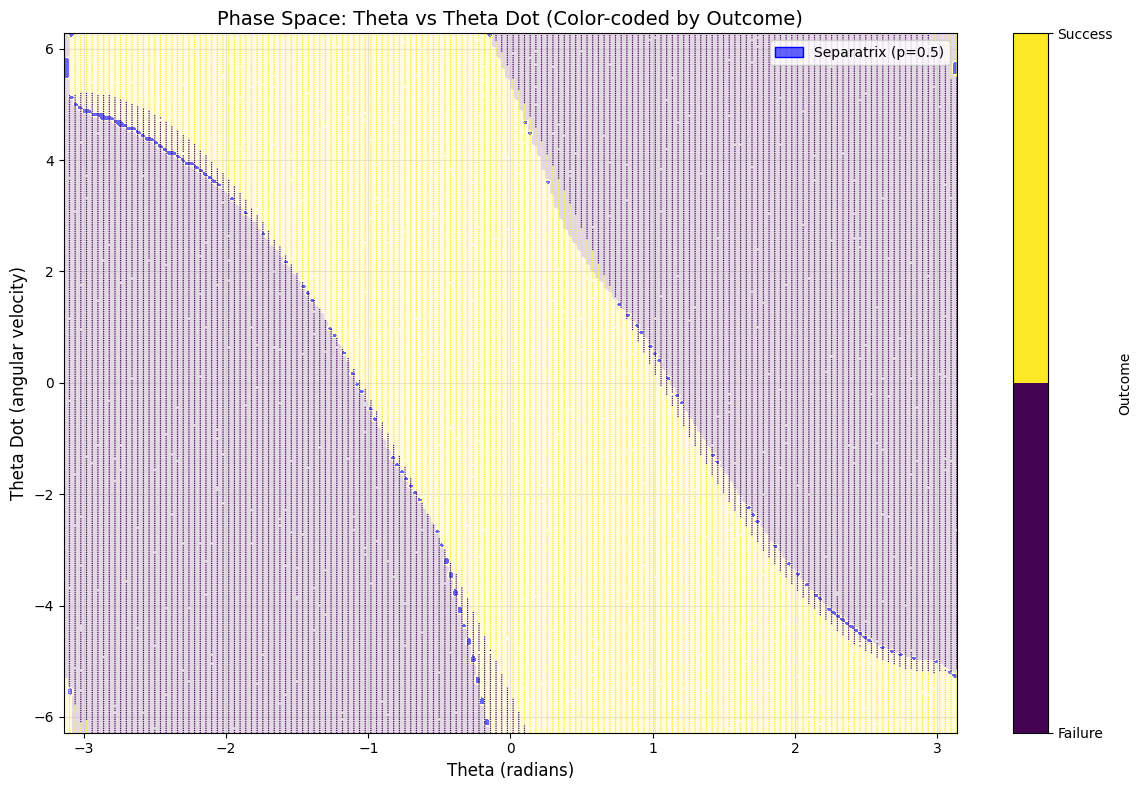

Plotted 49270 datapoints
  Theta range: [-3.142, 3.138] radians
  Theta_dot range: [-6.283, 6.277]
  Failure (Violet): 30265 datapoints
  Success (Yellow): 19005 datapoints


Getting model predictions for test data...
Computing separatrix (decision boundary)...


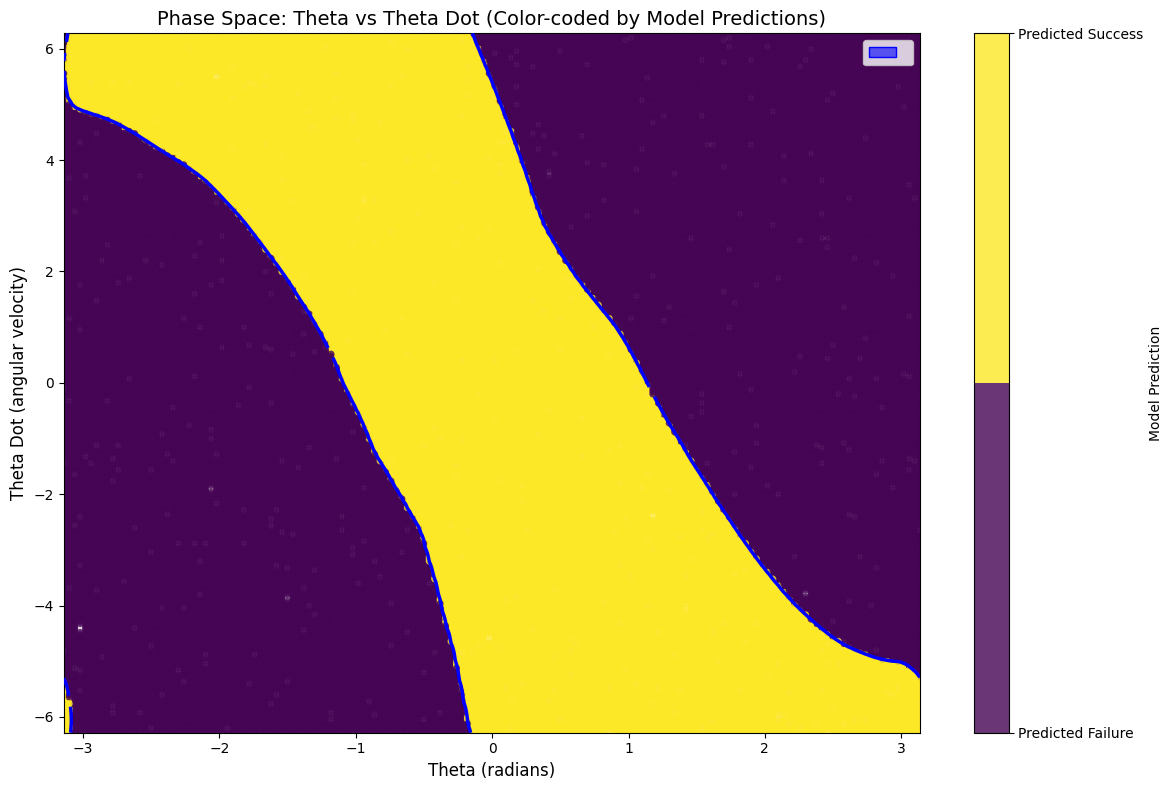

Plotted 49270 datapoints
  Theta range: [-3.142, 3.138] radians
  Theta_dot range: [-6.283, 6.277]
  Predicted Failure (Violet): 29307 datapoints (59.48%)
  Predicted Success (Yellow): 19963 datapoints (40.52%)


In [57]:
# Phase Space Plot: Theta vs Theta Dot
# For pendulum-lqr, X_test is 2D: (datapoints, features)
# Features are: [sin(theta), cos(theta), theta_dot] (already transformed and normalized)

from matplotlib.colors import ListedColormap, to_rgba

# Denormalize the data first to get actual physical values
X_test_denorm = X_test * feature_max

all_thetas = []
all_theta_dots = []

for i in range(len(X_test_denorm)):
    # X_test is 2D: (datapoints, features)
    # Features: [sin(theta), cos(theta), theta_dot]
    sin_theta = X_test_denorm[i, 0]  # sin(theta)
    cos_theta = X_test_denorm[i, 1]  # cos(theta)
    theta_dot = X_test_denorm[i, 2]  # theta_dot (already correct, no need to divide)
    
    # Convert sin/cos back to theta
    theta = np.arctan2(sin_theta, cos_theta)
    
    all_thetas.append(theta)
    all_theta_dots.append(theta_dot)

all_thetas = np.array(all_thetas)
all_theta_dots = np.array(all_theta_dots)

# Get model predictions for test data
print("Getting model predictions for test data...")
model.eval()
all_test_preds = []

with torch.no_grad():
    test_dataset = TimestepDataset(X_test, y_test)  # y_test not used, just for dataset structure
    test_loader = DataLoader(test_dataset, batch_size=512, shuffle=False, num_workers=0)
    
    for batch_X, _ in test_loader:
        batch_X = batch_X.to(device)
        outputs = model(batch_X)
        probs = torch.softmax(outputs, dim=1)
        prob_success = probs[:, 1].cpu().numpy()
        predicted = (prob_success >= 0.5).astype(int)  # Binary prediction
        
        all_test_preds.extend(predicted)

all_predictions = np.array(all_test_preds)

# Custom colors
failure_color = '#450354'  # Violet
success_color = '#FDE826'  # Yellow
separatrix_color = '#0000FF'  # Blue

# Create custom colormap with violet and yellow
custom_cmap = ListedColormap([failure_color, success_color])

# Compute separatrix (decision boundary) using the model
print("Computing separatrix (decision boundary)...")
theta_min, theta_max = all_thetas.min(), all_thetas.max()
theta_dot_min, theta_dot_max = all_theta_dots.min(), all_theta_dots.max()

# Create a grid for the separatrix
theta_grid = np.linspace(theta_min, theta_max, 200)
theta_dot_grid = np.linspace(theta_dot_min, theta_dot_max, 200)
THETA, THETA_DOT = np.meshgrid(theta_grid, theta_dot_grid)

# Convert grid points to model input format [sin(theta), cos(theta), theta_dot]
# and normalize
grid_sin = np.sin(THETA)
grid_cos = np.cos(THETA)
grid_theta_dot = THETA_DOT

# Normalize using feature_max
grid_X = np.stack([
    grid_sin / feature_max[0],
    grid_cos / feature_max[1], 
    grid_theta_dot / feature_max[2]
], axis=-1)

# Flatten for batch processing
grid_shape = grid_X.shape[:2]
grid_X_flat = grid_X.reshape(-1, 3)

# Get model predictions
model.eval()
with torch.no_grad():
    grid_X_tensor = torch.FloatTensor(grid_X_flat).to(device)
    grid_outputs = model(grid_X_tensor)
    grid_probs = torch.softmax(grid_outputs, dim=1)
    grid_prob_success = grid_probs[:, 1].cpu().numpy()

# Reshape back to grid
prob_grid = grid_prob_success.reshape(grid_shape)

# Create mask for separatrix regions
# Mask: 0 = failure region (p < 0.5), 1 = success region (p >= 0.5), 2 = boundary (p ≈ 0.5)
separatrix_mask = np.zeros_like(prob_grid)
separatrix_mask[prob_grid >= 0.5] = 1  # Success region
# Create boundary mask (within small threshold of 0.5)
boundary_threshold = 0.02
boundary_mask = np.abs(prob_grid - 0.5) < boundary_threshold
separatrix_mask[boundary_mask] = 2  # Boundary region

# Create phase space plot
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

# Plot separatrix mask as background (lowest z-order)
# Use a custom colormap: failure region (light violet), success region (light yellow), boundary (blue)
failure_rgba = to_rgba(failure_color, alpha=0.15)  # Light violet background
success_rgba = to_rgba(success_color, alpha=0.15)  # Light yellow background
boundary_rgba = to_rgba(separatrix_color, alpha=0.6)  # Blue boundary
mask_cmap = ListedColormap([failure_rgba, success_rgba, boundary_rgba])
im = ax.imshow(separatrix_mask, extent=[theta_min, theta_max, theta_dot_min, theta_dot_max], 
               origin='lower', aspect='auto', cmap=mask_cmap, interpolation='bilinear', zorder=1)

# Plot all datapoints, color-coded by model predictions (middle z-order)
scatter = ax.scatter(all_thetas, all_theta_dots, c=all_predictions, cmap=custom_cmap, s=25, alpha=0.8, edgecolors='none', zorder=2)

# Plot blue separatrix contour on top (highest z-order)
separatrix_contour = ax.contour(THETA, THETA_DOT, prob_grid, levels=[0.5], colors=[separatrix_color], 
                                linewidths=2.5, linestyles='solid', zorder=3)
ax.clabel(separatrix_contour, inline=True, fontsize=10, fmt='', zorder=4)

ax.set_xlabel('Theta (radians)', fontsize=12)
ax.set_ylabel('Theta Dot (angular velocity)', fontsize=12)
ax.set_title('Phase Space: Theta vs Theta Dot (Color-coded by Model Predictions)', fontsize=14)
ax.grid(True, alpha=0.3)

# Add colorbar with custom colors
cbar = plt.colorbar(scatter, ax=ax, ticks=[0, 1])
cbar.set_ticklabels(['Predicted Failure', 'Predicted Success'])
cbar.set_label('Model Prediction', fontsize=10)

# Add legend for separatrix mask
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=boundary_rgba, edgecolor=separatrix_color, label='')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

print(f"Plotted {len(all_thetas)} datapoints")
print(f"  Theta range: [{all_thetas.min():.3f}, {all_thetas.max():.3f}] radians")
print(f"  Theta_dot range: [{all_theta_dots.min():.3f}, {all_theta_dots.max():.3f}]")
print(f"  Predicted Failure (Violet): {np.sum(all_predictions == 0)} datapoints ({np.sum(all_predictions == 0)/len(all_predictions)*100:.2f}%)")
print(f"  Predicted Success (Yellow): {np.sum(all_predictions == 1)} datapoints ({np.sum(all_predictions == 1)/len(all_predictions)*100:.2f}%)")